In [63]:
import geopandas as gpd
import pandas as pd
import numpy as np
import geopy.distance
from shapely.geometry import Point, LineString, Polygon
from shapely.geometry import MultiPoint
import networkx as nx
import osmnx as ox
import osmnx.routing as routing
import random
import sys
import os
from pathlib import Path
import time
import pickle as pk

In [64]:
def load_file(file):
    with open(file, 'rb') as f:
        G = pk.load(f)
    return G

In [65]:
G_drive = load_file('../../Distance Matrix Construction/final_code_files/Dallas_bbox_drive.pkl')
#G_walk = load_file('../../Distance Matrix Constuction/final_code_files/Dallas_bbox_walk.pkl')

In [66]:
# !pwd

In [67]:
# G_drive

In [68]:
# G_drive = routing.add_edge_speeds(G_drive, agg = np.mean)
# G_drive = routing.add_edge_travel_times(G_drive)

In [69]:
def pickle_file(item, file_name):
    with open(file_name, 'wb') as f:
            G = pk.dump(item, f)
    return None

In [70]:
# pickle_file(G_drive, '../../Distance Matrix Construction/final_code_files/Dallas_bbox_drive.pkl')

In [71]:
G_walk = load_file('../../Distance Matrix Construction/final_code_files/Dallas_bbox_walk.pkl')

In [ ]:
sites = gpd.read_file('../../Parks/centroids.shp')

In [73]:
# # new_values_mins = {
# #     (u, v, k): data["length"] / (1.42*60)
# #     for u, v, k, data in G_walk.edges(keys=True, data=True)
# # }
# new_values_secs = {
#     (u, v, k): data["length"] / 1.42
#     for u, v, k, data in G_walk.edges(keys=True, data=True)
# }

In [74]:
# nx.set_edge_attributes(G_walk, name = "travel_time", values = new_values_secs)

In [75]:
# #checking if the changes were made
# edges = G_walk.edges
# print(list(edges)[0])
# print(G_walk.get_edge_data(list(edges)[0][0], list(edges)[0][1]))

In [76]:
# pickle_file(G_walk, '../../Distance Matrix Construction/final_code_files/Dallas_bbox_walk.pkl')

In [77]:
# #checking if drive graph changes were made
# edges_d = G_drive.edges
# print(list(edges_d)[0])
# print(G_drive.get_edge_data(list(edges_d)[0][0], list(edges_d)[0][1]))

DO NOT UNCOMMENT THE CODE ABOVE!!

In [87]:
eps_list = [5, 10, 20, 30]

In [153]:
def calc_iso_poly(G, center_node, time, edge_att = "travel_time"):
    subgraph = nx.ego_graph(G, 
                            center_node, 
                            radius = time * 60, 
                            distance = edge_att)

    node_points = [Point((data["x"], data["y"])) 
                   for node, data in subgraph.nodes(data = True)]

    polygon = Polygon(gpd.GeoSeries(node_points).union_all().convex_hull)
    
    return polygon

In [154]:
def run_full_iso(G, sites, eps_list):
    #calculate the nearest nodes for all points in the sites df

    #do this earlier in the code!!
    nodes = list(ox.distance.nearest_nodes(G, sites["geometry"].x, sites["geometry"].y))
    sites["nodes"] = nodes
    print('grabbed nodes', type(nodes))
    
    poly_df = gpd.GeoDataFrame(data = [], columns = ['node', 'eps', 'geometry'])
    
    for node in nodes:    
        print('working on node:',node)
        for time in eps_list:
            poly = calc_iso_poly(G, node, time)
            
            new_row = gpd.GeoDataFrame(
            {'node': [node], 
            'eps':[time]}, geometry = [poly], 
            crs="EPSG:4326"
            )

            poly_df = pd.concat([poly_df, new_row], ignore_index=True)
    return poly_df

In [156]:
poly_df = run_full_iso(G_walk, sites, eps_list)

grabbed nodes <class 'list'>
working on node: 4589982842
working on node: 81833668
working on node: 7833932683
working on node: 13622382626
working on node: 10080786944
working on node: 81573645
working on node: 81890489
working on node: 5783744268
working on node: 81722723
working on node: 7953637138
working on node: 10199948793
working on node: 82011299
working on node: 13347831257
working on node: 1797755996
working on node: 8525045633
working on node: 9856667002
working on node: 12965511343
working on node: 82005338
working on node: 10919415587
working on node: 4834782259


In [157]:
poly_df.head()

,node,eps,geometry
0,4589982842,5,"POLYGON ((-96.74554 32.73975, -96.7464 32.7418..."
1,4589982842,10,"POLYGON ((-96.74702 32.73706, -96.75082 32.741..."
2,4589982842,20,"POLYGON ((-96.75244 32.73195, -96.75524 32.733..."
3,4589982842,30,"POLYGON ((-96.75231 32.72792, -96.75793 32.728..."
4,81833668,5,"POLYGON ((-96.63565 32.74952, -96.63674 32.749..."


<Axes: >

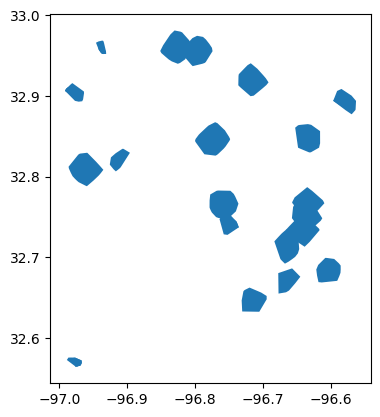

In [158]:
# poly_df['geometry'].plot()